In [90]:
%pip install eli5 lime shap seaborn
%pip install ucimlrepo  # For fetching dataset from UCI repository


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Member A: Logistic Regression + eli5 Interpretability
## CS667 Project 4: ML Interpretability

**Assigned Tasks:**
- EDA Focus: Feature correlations with target
- Model: Logistic Regression with GridSearchCV
- Interpretability: eli5 (Task 3_A)

**Prerequisites:** Run `00_data_preparation.ipynb` first!

---
# Part 1: Setup and Data Loading

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib

import eli5
from eli5.sklearn import PermutationImportance

# Shared constants
RANDOM_STATE = 42
TARGET_COLUMN = 'DEATH_EVENT'

In [92]:
# Load the pre-split data
train_data = pd.read_csv('../data/train.csv')
test_data = pd.read_csv('../data/test.csv')

# Also dropping time because it's too predictive.
X_train = train_data.drop(columns=[TARGET_COLUMN, 'time'])
y_train = train_data[TARGET_COLUMN]
X_test = test_data.drop(columns=[TARGET_COLUMN, 'time'])
y_test = test_data[TARGET_COLUMN]

feature_names = X_train.columns.tolist()

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {feature_names}")

Training samples: 89
Test samples: 210
Features: ['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking']


---
# Part 2: Exploratory Data Analysis

**Your EDA Focus**: Feature correlations, especially with the target variable.

### Investigation Prompts:
> - Which features have the strongest linear relationship with DEATH_EVENT?
> - Are there any highly correlated feature pairs that might cause multicollinearity issues for Logistic Regression?
> - How might you visualize the relationship between continuous features and a binary target?

In [93]:
# TODO: Create a correlation matrix including the target variable
# Hint: Use train_data (which includes target) for correlation analysis

pear_corr = train_data.corr(method='pearson')
spear_corr = train_data.corr(method='spearman')
kend_corr = train_data.corr(method='kendall')

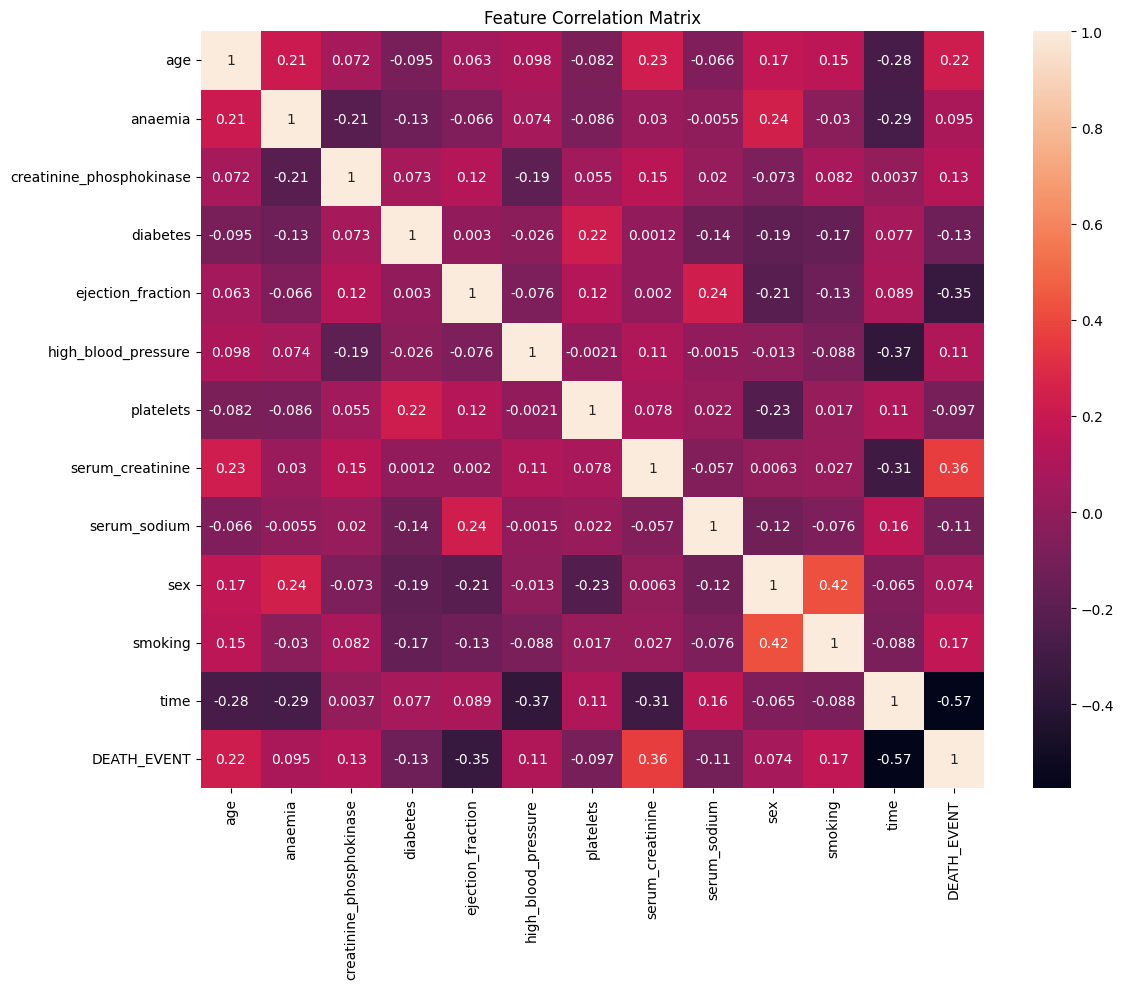

In [109]:
# TODO: Visualize the correlation matrix as a heatmap
# Hint: sns.heatmap() with annot=True shows values

plt.figure(figsize=(12, 10))
sns.heatmap(pear_corr, annot=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('../visualizations/correlation_matrix.png', dpi=150)
plt.show()

# plt.figure(figsize=(12, 10))
# sns.heatmap(spear_corr, annot=True)
# plt.title('Feature Correlation Matrix')
# plt.tight_layout()
# plt.savefig('../visualizations/correlation_matrix.png', dpi=150)
# plt.show()

# plt.figure(figsize=(12, 10))
# sns.heatmap(kend_corr, annot=True)
# plt.title('Feature Correlation Matrix')
# plt.tight_layout()
# plt.savefig('../visualizations/correlation_matrix.png', dpi=150)
# plt.show()

In [95]:
# TODO: Extract and rank correlations with the target variable
# Which features correlate most strongly (positive or negative) with DEATH_EVENT?

items = list(pear_corr[TARGET_COLUMN].items())
sorted_items = sorted(items, key = lambda item: abs(item[1]), reverse=True)
# YOUR CODE HERE
# print(sorted_items)
for key, value in sorted_items:
    print(f"{key} : {round(value, 4)}")


DEATH_EVENT : 1.0
time : -0.5748
serum_creatinine : 0.3646
ejection_fraction : -0.3466
age : 0.2194
smoking : 0.1718
diabetes : -0.1303
creatinine_phosphokinase : 0.1258
high_blood_pressure : 0.1109
serum_sodium : -0.11
platelets : -0.0969
anaemia : 0.0954
sex : 0.0741


### EDA Findings:

*Document your key observations here:*

Note that we will be dropping Time as a predictive feature because it is measuring the overall level of someones health distress, and will not be a usefull predictor a real-world implementation of this predictive pipeline.

1. Strongest positive correlations with DEATH_EVENT: serum_creatinine
2. Strongest negative correlations with DEATH_EVENT: ejection_fraction
3. Notable feature-feature correlations: Time is corrilated with serum_creatinine, anaemia and high_blood_pressure. These conditions may be predictive of frequent hospital visits(or require them). Smoking and Sex are also moderatly corrilated.... Anemia and Sex are also mildly corrilated, which is expected: women are more likely to be anemic. 
4. Implications for Logistic Regression: We have 2 factors with over a .3 corrilation, and two that are in the teens. I anticipate that we will have a fairly high accuracy. 

---
# Part 3: Logistic Regression Modeling

### Investigation Prompts:
> - Why might scaling features be important for Logistic Regression?
> - What do the hyperparameters C, penalty, and solver control?
> - How does regularization (L1 vs L2) affect feature selection?

Scaling Might be important to logistic regression because it makes sure that our features fit well into a geometric space.



In [96]:
# TODO: Scale the features
# Hint: Fit the scaler on training data only, then transform both train and test

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled.")

Features scaled.


In [97]:
# TODO: Define the hyperparameter grid for GridSearchCV
# Consider: C (regularization strength), penalty (l1, l2), solver

param_grid = {
    # YOUR CODE HERE
    # Hint: 'C': [0.001, 0.01, 0.1, 1, 10, 100]
    # Hint: 'penalty': ['l1', 'l2']
    # Hint: 'solver': ['liblinear', 'saga']  # These support both l1 and l2
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced', {0: .4, 1: .6}, {0: .42, 1: .58}, {0: .44, 1: .56}, {0: .46, 1: .54}, {0: .48, 1: .52} ],
    'solver': ['liblinear', 'saga']

}

print(f"Parameter grid: {param_grid}")

Parameter grid: {'penalty': ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100], 'class_weight': [None, 'balanced', {0: 0.4, 1: 0.6}, {0: 0.42, 1: 0.58}, {0: 0.44, 1: 0.56}, {0: 0.46, 1: 0.54}, {0: 0.48, 1: 0.52}], 'solver': ['liblinear', 'saga']}


In [98]:
# TODO: Perform GridSearchCV
# Use cv=5, scoring='roc_auc' as specified in project requirements

lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

grid_search = GridSearchCV(
    lr, param_grid=param_grid
)

# Fit the grid search
# YOUR CODE HERE
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV AUC-ROC: {grid_search.best_score_:.4f}")

Best parameters: {'C': 1, 'class_weight': {0: 0.46, 1: 0.54}, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC-ROC: 0.8203


In [99]:
# Get the best model
best_lr = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_lr.predict(X_test_scaled)
y_proba = best_lr.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"\n=== Logistic Regression Results ===")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC-ROC: {auc_roc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))


=== Logistic Regression Results ===
Test Accuracy: 0.7667
Test AUC-ROC: 0.7462

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       143
           1       0.67      0.54      0.60        67

    accuracy                           0.77       210
   macro avg       0.73      0.71      0.72       210
weighted avg       0.76      0.77      0.76       210



In [100]:
# Save the model and scaler for team merge
joblib.dump(best_lr, '../models/logistic_regression_best.pkl')
joblib.dump(scaler, '../models/lr_scaler.pkl')
print("Model and scaler saved to ../models/")

Model and scaler saved to ../models/


---
# Part 4: eli5 Interpretability (Task 3_A)

## eli5 Investigation Prompts

> **Before you code, research these questions:**
> 
> 1. What does `eli5.show_weights()` display for a Logistic Regression model?
> 2. How do you interpret positive vs negative weights in binary classification?
> 3. What is the relationship between LR coefficients and odds ratios?
> 4. When using `eli5.show_prediction()`, what information explains a single prediction?
> 5. How does feature scaling affect the interpretation of weights?

### 4.1 Visualize Feature Weights

In [101]:
print(X_test.columns)

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking'],
      dtype='object')


In [102]:
# TODO: Use eli5.show_weights() to visualize the model weights
# Hint: Pass feature_names to make the output readable

eli5.show_weights(best_lr, feature_names=list(X_test.columns))

# Balance of 4:6 (alive:dead)
#  Drooped Sex and Serium Sodium.

Weight?,Feature
+1.319,serum_creatinine
+0.323,age
+0.200,smoking
+0.106,high_blood_pressure
+0.084,creatinine_phosphokinase
+0.082,anaemia
-0.098,platelets
-0.187,diabetes
-0.574,<BIAS>
-0.899,ejection_fraction


In [103]:
# TODO: Extract weights as a DataFrame for further analysis
# Hint: eli5.explain_weights_df() returns a DataFrame

# YOUR CODE HERE
extracted_weights = eli5.explain_weights_df(best_lr, feature_names=list(X_train.columns))
print(extracted_weights)

   target                   feature    weight
0       1          serum_creatinine  1.318882
1       1                       age  0.322587
2       1                   smoking  0.199664
3       1       high_blood_pressure  0.105574
4       1  creatinine_phosphokinase  0.083886
5       1                   anaemia  0.082212
6       1                 platelets -0.097788
7       1                  diabetes -0.187384
8       1                    <BIAS> -0.574178
9       1         ejection_fraction -0.899105


### 4.2 Explain Specific Predictions

**Task**: Pick one test example with a positive label (death=1) and one with a negative label (death=0).

### Investigation Prompt:
> What features contribute most to pushing the prediction toward each class? How does eli5 show this contribution?

In [117]:
# Find indices of positive and negative examples in test set
positive_idx = y_test[y_test == 1].index[10]  # First positive example
negative_idx = y_test[y_test == 0].index[10]  # First negative example
POSITIVE_EXAMPLE_IDX = 55
NEGATIVE_EXAMPLE_IDX = 131
print(f"Positive example index: {positive_idx}")
print(f"Negative example index: {negative_idx}")

Positive example index: 18
Negative example index: 23


In [121]:
# TODO: Explain prediction for POSITIVE example (death=1)
# Hint: Use eli5.show_prediction() with the scaled features

print("=== Explanation for POSITIVE Example (True Label: Death) ===")
# Get the row from scaled test data
# YOUR CODE HERE

pos_row = X_train_scaled[positive_idx]
eli5.show_prediction(best_lr, pos_row, feature_names = X_train.columns.to_list())

=== Explanation for POSITIVE Example (True Label: Death) ===


In [130]:
# TODO: Explain prediction for NEGATIVE example (death=0)

print("=== Explanation for NEGATIVE Example (True Label: Survived) ===")
# YOUR CODE HERE

neg_row = X_test_scaled[negative_idx]
print(neg_row)
eli5.show_prediction(best_lr, neg_row, feature_names = X_train.columns.to_list())

=== Explanation for NEGATIVE Example (True Label: Survived) ===
[-0.73185541  1.03429563  0.20916601 -0.64241607  0.03787093 -0.82416338
  0.75114756  0.02932491  0.08057297  0.69522179  1.64570147]


### 4.3 Interpretation Summary

*Document your interpretability findings:*

1. **Top 3 features pushing toward death (positive weights):**
   - Feature 1: ... (weight: ...)
   - Feature 2: ...
   - Feature 3: ...

2. **Top 3 features pushing toward survival (negative weights):**
   - Feature 1: ... (weight: ...)
   - Feature 2: ...
   - Feature 3: ...

3. **Positive example explanation:**
   - Which features contributed most to the death prediction?
   - Does this align with clinical intuition?

4. **Negative example explanation:**
   - Which features contributed most to the survival prediction?
   - Any surprising findings?

---
# Part 5: Individual Predictions for Task 4

Provide predictions with probabilities for the team's agreed-upon examples.

In [107]:
# TODO: Fill in the agreed indices from team discussion in 00_data_preparation.ipynb
POSITIVE_EXAMPLE_IDX = 55
NEGATIVE_EXAMPLE_IDX = 131

if POSITIVE_EXAMPLE_IDX is None or NEGATIVE_EXAMPLE_IDX is None:
    print("WARNING: Update the example indices with team-agreed values!")

In [108]:
# Generate predictions for Task 4 comparison
# This format will be used in the final merge

def predict_with_proba(model, X_scaled, idx, true_label):
    """Generate prediction output for Task 4 format."""
    # Find position of idx in the data
    pos = list(X_test.index).index(idx)
    sample = X_scaled[pos:pos+1]
    
    proba = model.predict_proba(sample)[0]
    pred = model.predict(sample)[0]
    
    print(f"True Label: {true_label}")
    print(f"LR Prediction: {pred}")
    print(f"LR Probabilities: [P(Survive)={proba[0]:.4f}, P(Death)={proba[1]:.4f}]")
    return proba

if POSITIVE_EXAMPLE_IDX is not None:
    print("=== Positive Example ===")
    predict_with_proba(best_lr, X_test_scaled, POSITIVE_EXAMPLE_IDX, 1)
    
    print("\n=== Negative Example ===")
    predict_with_proba(best_lr, X_test_scaled, NEGATIVE_EXAMPLE_IDX, 0)

=== Positive Example ===
True Label: 1
LR Prediction: 0
LR Probabilities: [P(Survive)=0.9046, P(Death)=0.0954]

=== Negative Example ===
True Label: 0
LR Prediction: 0
LR Probabilities: [P(Survive)=0.6625, P(Death)=0.3375]


---
# Part 6: Summary for Merge

### Key Results to Include in Final Submission:

| Metric | Value |
|--------|-------|
| Best Hyperparameters | {'C': 1, 'class_weight': {0: 0.46, 1: 0.54}, 'penalty': 'l1', 'solver': 'liblinear'} |
| Test Accuracy | 0.7667 |
| Test AUC-ROC | 0.7462 |

### Files Saved for Team:
- `../models/logistic_regression_best.pkl`
- `../models/lr_scaler.pkl`
- `../visualizations/correlation_matrix.png`

### Key Interpretability Findings:
1. Class weights can be used to adust for class imbalance. This is a more graceful solution than SMOTE or generating synthetic data.
2. The predictors for Death and Survival are different, which is interesting, but also makes sense. 
3. ...